In [1]:
!nvidia-smi

Sat Jun 20 13:13:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   40C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!pip install torchmetrics tqdm mlxtend

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 26.6 MB/s eta 0:00:00


In [3]:
#Import required libraries
import torch
from torchvision import datasets
from torchvision import transforms
from torchmetrics import Accuracy
from torch.utils.data import DataLoader, TensorDataset
from torch import nn
from tqdm.auto import tqdm
import matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

#Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [4]:
DATASET_FILENAME = 'stock_prices.csv'

# Load the dataset into a pandas DataFrame for analysis
df = pd.read_csv(DATASET_FILENAME)

In [5]:
df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


In [25]:
df.shape

(497472, 7)

In [33]:
#df1 = df.loc[df['symbol'].isin(['AAL','AAPL','AAP','ABBV','ABC'])].copy()
df1 = df.loc[df['symbol'] == 'AAPL'].copy()
df1.head()

,symbol,date,open,high,low,close,volume
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
484,AAPL,2014-01-03,78.9799,79.0999,77.2042,77.2828,98303870
967,AAPL,2014-01-06,76.7785,78.1142,76.2285,77.7042,103359151
1450,AAPL,2014-01-07,77.7599,77.9942,76.8464,77.1481,79432766
1933,AAPL,2014-01-08,76.9728,77.9371,76.9556,77.6371,64686685


In [34]:
df1.shape

(1007, 7)

In [35]:
def create_sequences(data, seq_length):
    xs = []
    ys = []
    for i in range(len(data)-seq_length-1):
        x = data[i:(i+seq_length)]
        y = data[i+seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

daily_close = df1['close'].values.reshape(-1, 1)

seq_length = 9 # Use 9 past days to predict next
X, y = create_sequences(daily_close, seq_length)

# Split into train and test
train_size = int(len(X) * 0.8)
X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, 1)).reshape(X_train.shape)
X_test = scaler.transform(X_test.reshape(-1, 1)).reshape(X_test.shape)
y_train = scaler.transform(y_train.reshape(-1, 1)).reshape(y_train.shape)
y_test = scaler.transform(y_test.reshape(-1, 1)).reshape(y_test.shape)

# Convert NumPy arrays to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test, dtype=torch.float32).to(device)

train_data = TensorDataset(X_train, y_train)
test_data = TensorDataset(X_test, y_test)

batch_size = 16
train_loader = DataLoader(train_data, shuffle=False, batch_size=batch_size, drop_last=True)
test_loader = DataLoader(test_data, shuffle=False, batch_size=batch_size, drop_last=True)
print(f"Train samples: {len(train_data)}, Test samples: {len(test_data)}")

Train samples: 797, Test samples: 200


In [36]:
def train_model(model, epochs=100):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.1) # Note: Keeping the learning rate high for demonstrating vanishing gradients in RNNs.

    train_losses = []

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        train_losses.append(epoch_loss/len(train_loader))
        if (epoch+1) % 10 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(train_loader):.4f}')

    return train_losses

def evaluate_model(model):
    model.eval()
    criterion = nn.MSELoss()
    test_loss = 0
    predictions = []
    actuals = []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            test_loss += loss.item()
            predictions.extend(outputs.cpu().numpy())
            actuals.extend(y_batch.cpu().numpy())
    return test_loss/len(test_loader), predictions, actuals

In [37]:
class SimpleRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1):
        super(SimpleRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, hidden_size//2)
        self.out = nn.Linear(hidden_size//2, output_size)
        self.activation = nn.GELU()

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.rnn(x, h0)
        # Get the output from the last timestep
        out = out[:, -1, :]
        out = self.fc1(out)
        out = self.activation(out)
        out = self.out(out)
        return out

rnn_model = SimpleRNN().to(device)
print("Training RNN...")
rnn_train_losses = train_model(rnn_model)
rnn_test_loss, rnn_preds, rnn_actuals = evaluate_model(rnn_model)
print(f'RNN Test Loss: {rnn_test_loss:.4f}')

Training RNN...
Epoch 10/100, Loss: 0.0850
Epoch 20/100, Loss: 0.0859
Epoch 30/100, Loss: 0.0861
Epoch 40/100, Loss: 0.0862
Epoch 50/100, Loss: 0.0862
Epoch 60/100, Loss: 0.0863
Epoch 70/100, Loss: 0.0863
Epoch 80/100, Loss: 0.0863
Epoch 90/100, Loss: 0.0863
Epoch 100/100, Loss: 0.0863
RNN Test Loss: 0.6822


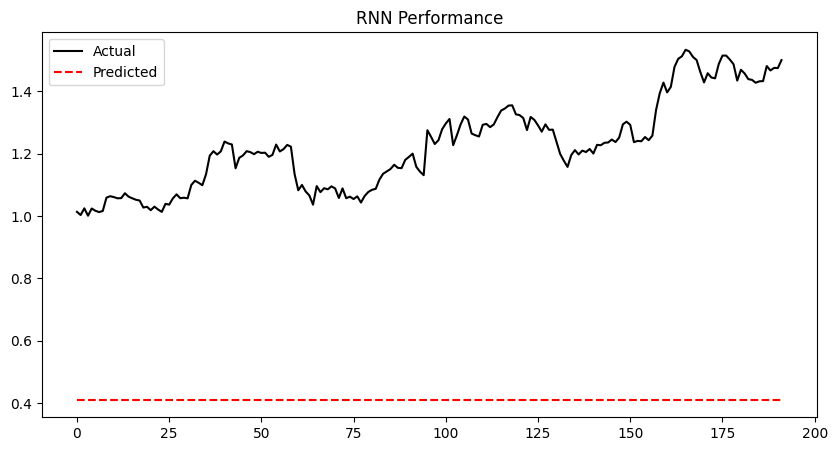

In [38]:
plt.figure(figsize=(10, 5))
plt.plot(rnn_actuals, label='Actual', color='black')
plt.plot(rnn_preds, label='Predicted', color='red', linestyle='--')
plt.title('RNN Performance')
plt.legend()
plt.show()

In [39]:
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, hidden_size//2)
        self.out = nn.Linear(hidden_size//2, output_size)
        self.activation = nn.GELU()

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        out = self.fc1(out)
        out = self.activation(out)
        out = self.out(out)
        return out

lstm_model = LSTMModel().to(device)
print("Training LSTM...")
lstm_train_losses = train_model(lstm_model)
lstm_test_loss, lstm_preds, lstm_actuals = evaluate_model(lstm_model)
print(f'LSTM Test Loss: {lstm_test_loss:.4f}')

Training LSTM...
Epoch 10/100, Loss: 0.0849
Epoch 20/100, Loss: 0.0859
Epoch 30/100, Loss: 0.0861
Epoch 40/100, Loss: 0.0862
Epoch 50/100, Loss: 0.0862
Epoch 60/100, Loss: 0.0863
Epoch 70/100, Loss: 0.0863
Epoch 80/100, Loss: 0.0863
Epoch 90/100, Loss: 0.0863
Epoch 100/100, Loss: 0.0863
LSTM Test Loss: 0.6822


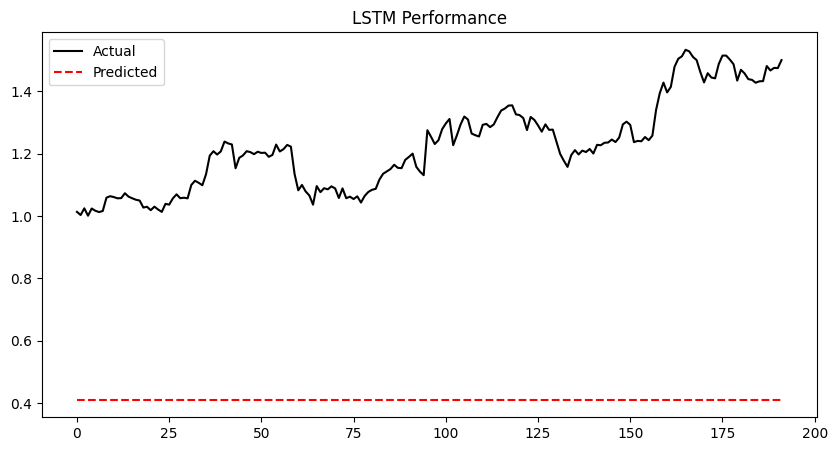

In [40]:
plt.figure(figsize=(10, 5))
plt.plot(lstm_actuals, label='Actual', color='black')
plt.plot(lstm_preds, label='Predicted', color='red', linestyle='--')
plt.title('LSTM Performance')
plt.legend()
plt.show()

In [41]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=1, output_size=1):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc1 = nn.Linear(hidden_size, hidden_size//2)
        self.out = nn.Linear(hidden_size//2, output_size)
        self.activation = nn.GELU()

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.gru(x, h0)
        out = out[:, -1, :]
        out = self.fc1(out)
        out = self.activation(out)
        out = self.out(out)
        return out

gru_model = GRUModel().to(device)
print("Training GRU...")
gru_train_losses = train_model(gru_model)
gru_test_loss, gru_preds, gru_actuals = evaluate_model(gru_model)
print(f'GRU Test Loss: {gru_test_loss:.4f}')

Training GRU...
Epoch 10/100, Loss: 0.0842
Epoch 20/100, Loss: 0.0909
Epoch 30/100, Loss: 0.0222
Epoch 40/100, Loss: 0.0868
Epoch 50/100, Loss: 0.0887
Epoch 60/100, Loss: 0.0876
Epoch 70/100, Loss: 0.0869
Epoch 80/100, Loss: 0.0866
Epoch 90/100, Loss: 0.0864
Epoch 100/100, Loss: 0.0864
GRU Test Loss: 0.6816


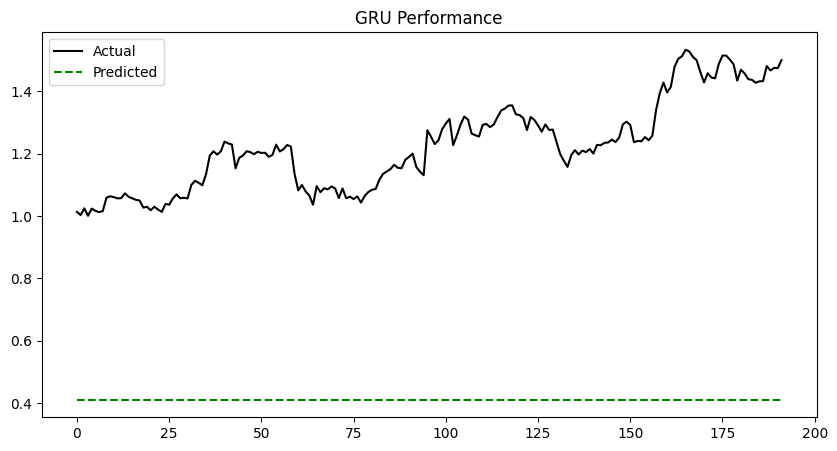

In [42]:
plt.figure(figsize=(10, 5))
plt.plot(gru_actuals, label='Actual', color='black')
plt.plot(gru_preds, label='Predicted', color='green', linestyle='--')
plt.title('GRU Performance')
plt.legend()
plt.show()

***Compare Models***

In [43]:
print(f"RNN Test Loss:  {rnn_test_loss:.4f}")
print(f"LSTM Test Loss: {lstm_test_loss:.4f}")
print(f"GRU Test Loss:  {gru_test_loss:.4f}")

RNN Test Loss:  0.6822
LSTM Test Loss: 0.6822
GRU Test Loss:  0.6816


In [44]:
rnn_r2 = r2_score(rnn_actuals, rnn_preds)
lstm_r2 = r2_score(lstm_actuals, lstm_preds)
gru_r2 = r2_score(gru_actuals, gru_preds)
print(f"RNN R² Score:  {rnn_r2:.4f}")
print(f"LSTM R² Score: {lstm_r2:.4f}")
print(f"GRU R² Score:  {gru_r2:.4f}")

RNN R² Score:  -31.5901
LSTM R² Score: -31.5901
GRU R² Score:  -31.5613


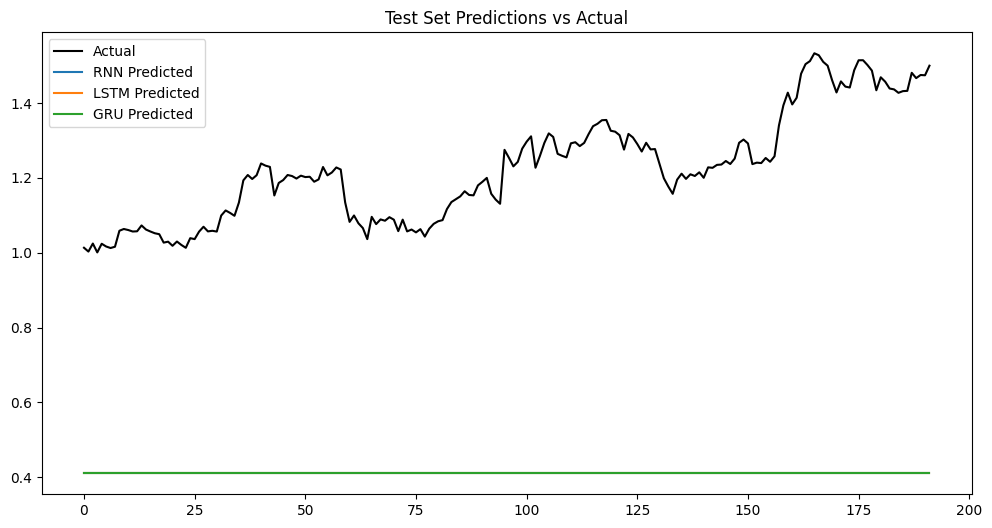

In [45]:
plt.figure(figsize=(12, 6))
plt.plot(rnn_actuals, label='Actual', color='black')
plt.plot(rnn_preds, label='RNN Predicted')
plt.plot(lstm_preds, label='LSTM Predicted')
plt.plot(gru_preds, label='GRU Predicted')
plt.title('Test Set Predictions vs Actual')
plt.legend()
plt.show()